# Mean Reversion Strategy Bitcoin - Strategy

1. [Download Data](#download-data)
2. [Test Stationarity](#test-stationarity)
3. [Cointegration Test](#cointegration-test)
4. [Modeling the Strategy](#modeling-the-strategy)


# Download Data

Data can be downloaded from sources such as Yahoo Finance, Polygon, Metatrader...

---

C:\Users\jango\AppData\Local\Temp\ipykernel_2348\722634244.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bitcoin = yf.download(
[*********************100%***********************]  1 of 1 completed
C:\Users\jango\AppData\Local\Temp\ipykernel_2348\722634244.py:27: FutureWarning: YF.download() has changed argument auto_adjust default to True
  strategy = yf.download(
[*********************100%***********************]  1 of 1 completed


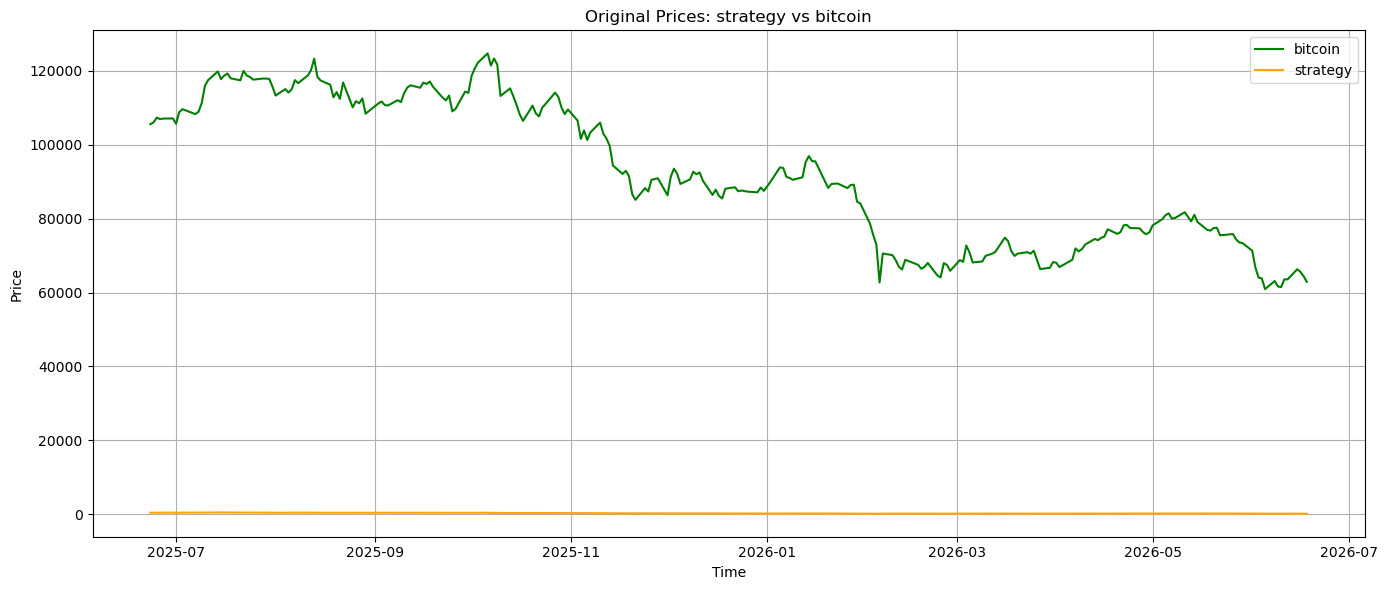

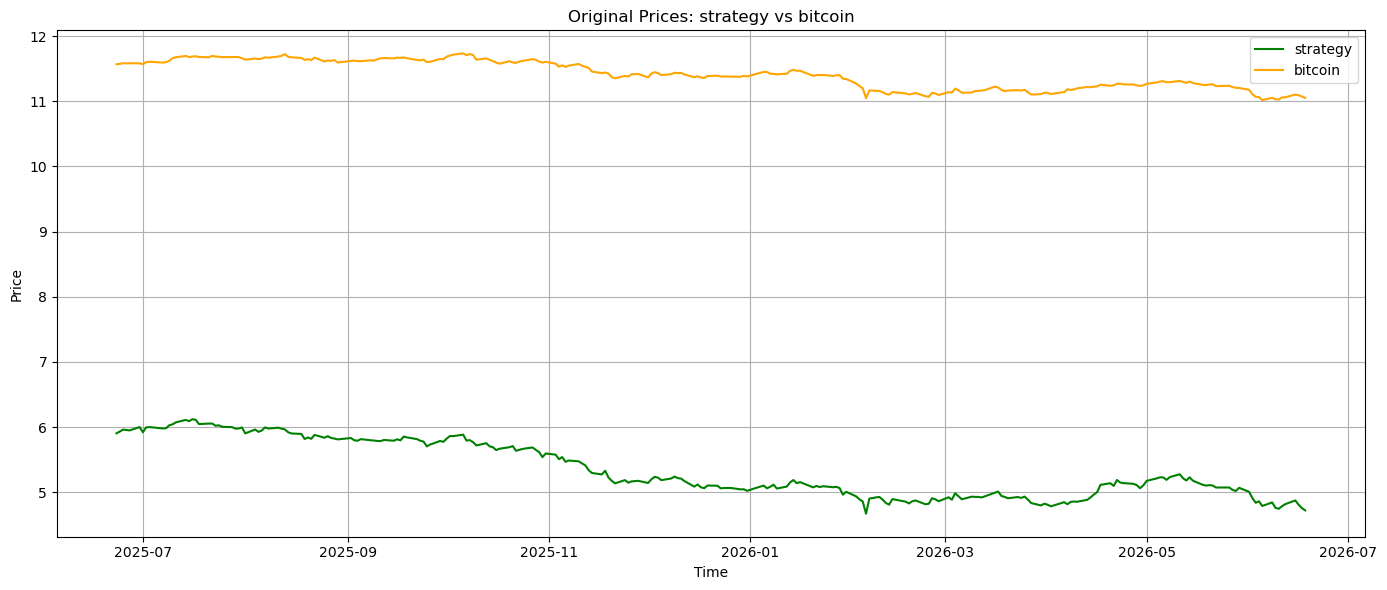

Bitcoin Buy-and-Hold Return (last 365 days): -40.43%
Strategy Buy-and-Hold Return (last 365 days): -69.35%
BTC Sharpe ratio diario: -0.06
Strategy Sharpe ratio diario: -0.08


In [1]:
# ===========================================
# Import required libraries
# ===========================================
import pandas as pd  # For data manipulation (install: pip install pandas)
import yfinance as yf  # Yahoo Finance API wrapper (install: pip install yfinance)
from datetime import datetime, timedelta  # To work with time ranges
from yahooquery import search  # For searching assets (install: pip install yahooquery)
import os  # To interact with the file system
import matplotlib.pyplot as plt  # For visualization (install: pip install matplotlib)
import json #For data manipulation
import numpy as np


# ===========================================
# Load environment variables
# ===========================================


bitcoin = yf.download(
    tickers= "BTC-USD",
    interval='1d',
    period='365d',
    progress=True,
    threads=True  # Enable multi-threading for faster downloading
)

strategy = yf.download(
    tickers= "MSTR",
    interval='1d',
    period='365d',
    progress=True,
    threads=True  # Enable multi-threading for faster downloading
)

btc_close = bitcoin['Close']
strategy_close = strategy['Close'] 

btc_close = btc_close['BTC-USD']  #  Series
strategy_close = strategy_close['MSTR']  #  Series

bitcoin = np.log(bitcoin)
strategy = np.log(strategy)

common_dates = bitcoin.index.intersection(strategy.index)
bitcoin = bitcoin.loc[common_dates]
strategy = strategy.loc[common_dates]

btc_close = btc_close.loc[common_dates]
strategy_close = strategy_close.loc[common_dates]


# ======== Plot original prices: bitcoin vs strategy ===========
plt.figure(figsize=(14, 6))
plt.plot(btc_close, label='bitcoin', color='green')
plt.plot(strategy_close, label='strategy', color='orange')
plt.title('Original Prices: strategy vs bitcoin')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ======== Plot original prices: bitcoin vs strategy ===========
plt.figure(figsize=(14, 6))
plt.plot(strategy[('Close','MSTR')], label='strategy', color='green')
plt.plot(bitcoin[( 'Close','BTC-USD')], label='bitcoin', color='orange')
plt.title('Original Prices: strategy vs bitcoin')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Buy-and-hold return in percentage
btc_return = (btc_close.iloc[-1] - btc_close.iloc[0]) / btc_close.iloc[0] * 100
strategy_return = (strategy_close.iloc[-1] - strategy_close.iloc[0]) / strategy_close.iloc[0] * 100

print(f"Bitcoin Buy-and-Hold Return (last 365 days): {btc_return:.2f}%")
print(f"Strategy Buy-and-Hold Return (last 365 days): {strategy_return:.2f}%")

# Retornos diarios
btc_daily_ret = btc_close.pct_change().dropna()
strategy_daily_ret = strategy_close.pct_change().dropna()

# Sharpe ratio anualizado (suponiendo 252 días de trading)
btc_sharpe = (btc_daily_ret.mean() / btc_daily_ret.std()) 
strategy_sharpe = (strategy_daily_ret.mean() / strategy_daily_ret.std()) 
print(f"BTC Sharpe ratio diario: {btc_sharpe:.2f}")
print(f"Strategy Sharpe ratio diario: {strategy_sharpe:.2f}")



### Create Stationary Series Using OLS

The stationary series is calculated by subtracting the trend fitted by an Ordinary Least Squares (OLS) model, returning the residuals as the stationary series.

---

**Alpha**: The intercept term in the OLS regression, representing the constant part of the relationship between the two series.

**Beta**: The slope term in the OLS regression, representing the sensitivity of the dependent variable (the first asset) to the independent variable (the second asset). It indicates the strength and direction of the relationship between the two series.


C:\Users\jango\AppData\Local\Temp\ipykernel_2348\1340339112.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hedge_ratio = model.params[1]  # The coefficient of the second asset


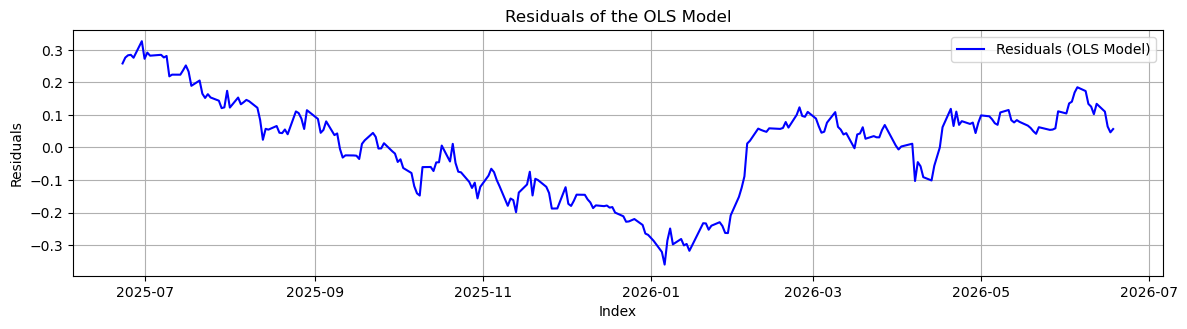

In [2]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from arch.__future__ import reindexing
from arch import unitroot

# Step 1: Define the dependent and independent variables
Y = strategy[('Close','MSTR')]
X = bitcoin[( 'Close','BTC-USD')]
X = sm.add_constant(X)  # Add an intercept (constant) to the model

# Step 2: Fit the OLS model
model = sm.OLS(Y, X).fit()
hedge_ratio = model.params[1]  # The coefficient of the second asset 

# residuals are the difference between the observed and predicted values from the model
residuals = model.resid  # Residuals from the OLS model

# Plot both the residuals from the OLS model and the manually calculated residuo
plt.figure(figsize=(12, 6))

# Plot residuals from the OLS model
plt.subplot(2, 1, 1)  # First plot
plt.plot(residuals, label='Residuals (OLS Model)', color='blue')
plt.title('Residuals of the OLS Model')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Test Stationarity

To test for stationarity, you can use the **Augmented Dickey-Fuller (ADF)** test (differents results depending on which is the independent variable).

---

In [8]:
from statsmodels.tsa.stattools import adfuller
from hurst import compute_Hc
from arch.unitroot import VarianceRatio

# Assume 'residuals' is already a list or 1D array-like series of residuals
# Example: residuals = [values from your cointegration model]

# --- ADF Test ---
adf_result = adfuller(residuals)
adf_statistic = adf_result[0]
adf_p_value = adf_result[1]

print("ADF Test:")
print(f"Statistic: {adf_statistic}")
print(f"P-value: {adf_p_value}")
if adf_p_value < 0.05:
    print("Residuals are stationary (reject null hypothesis of unit root).")
else:
    print("Residuals are not stationary (fail to reject null hypothesis).")

# Ensure residuals are strictly positive
residuals1 = [r - min(residuals) + 1 for r in residuals]


# --- Hurst Exponent --- Not recomended for 
H, c, _ = compute_Hc(residuals1, kind='price')
print("\nHurst Exponent:")
print(f"H: {H}")
if H < 0.5:
    print("Series shows mean-reverting behavior.")
elif H > 0.5:
    print("Series shows trending behavior.")
else:
    print("Series behaves like a random walk.")

# --- Variance Ratio Test ---
vr_test = VarianceRatio(residuals1, lags=2)
print("\nVariance Ratio Test:")
print(f"Variance Ratio: {vr_test.vr}")
print(f"P-value: {vr_test.pvalue}")
if vr_test.vr < 1:
    print("Variance ratio suggests mean reversion.")
elif vr_test.vr > 1:
    print("Variance ratio suggests momentum.")
else:
    print("Variance ratio suggests random walk.")




ADF Test:
Statistic: -2.101968549018016
P-value: 0.243723775182918
Residuals are not stationary (fail to reject null hypothesis).

Hurst Exponent:
H: 0.6713673695029079
Series shows trending behavior.

Variance Ratio Test:
Variance Ratio: 0.8935995535501913
P-value: 0.14378643146155512
Variance ratio suggests mean reversion.


## Half-Life for Mean Reverting Process

This section estimates the half-life of mean reversion for a stationary portfolio 
derived from cointegrated assets using the first eigenvector from the Johansen test.



In [ ]:
import statsmodels.api as sm
import numpy as np
import pandas as pd

# --- 1. Build the Asset Matrix ---
Y = pd.DataFrame({
    'strategy': strategy[('Close', 'MSTR')],
    'bitcoin': bitcoin[('Close', 'BTC-USD')]
})


yport = Y['strategy'] - (hedge_ratio * Y['bitcoin'])

ylag = yport.shift(1)

deltaY = yport - ylag

deltaY = deltaY.dropna()
ylag = ylag.dropna()


# Add a constant term (intercept) to the independent variable matrix
X = sm.add_constant(ylag)  

# Fit the OLS model: deltaY = alpha + lambda * ylag
model = sm.OLS(deltaY, X)  
results_ols = model.fit()  

# --- 5. Extract Parameters and Calculate Half-Life ---
# results_ols.params.iloc[0] is the constant intercept (alpha)
# results_ols.params.iloc[1] is the mean reversion speed coefficient (lambda)
lambda_coefficient = results_ols.params.iloc[1]

# Calculate the half-life in days
half_life = -np.log(2) / lambda_coefficient

print("--- OLS Estimation Results ---")
print(results_ols.params)
print("-" * 30)
print(f'Mean Reversion Speed (Lambda): {lambda_coefficient:.6f}')
print(f'Half-Life: {half_life:.2f} days')

--- OLS Estimation Results ---
const    0.019818
0       -0.004598
dtype: float64
------------------------------
Mean Reversion Speed (Lambda): -0.004598
Half-Life: 150.74 days


# Modeling the Strategy

You will use techniques such as z-scores, Bollinger Bands, and linear regression to model your strategy.

---

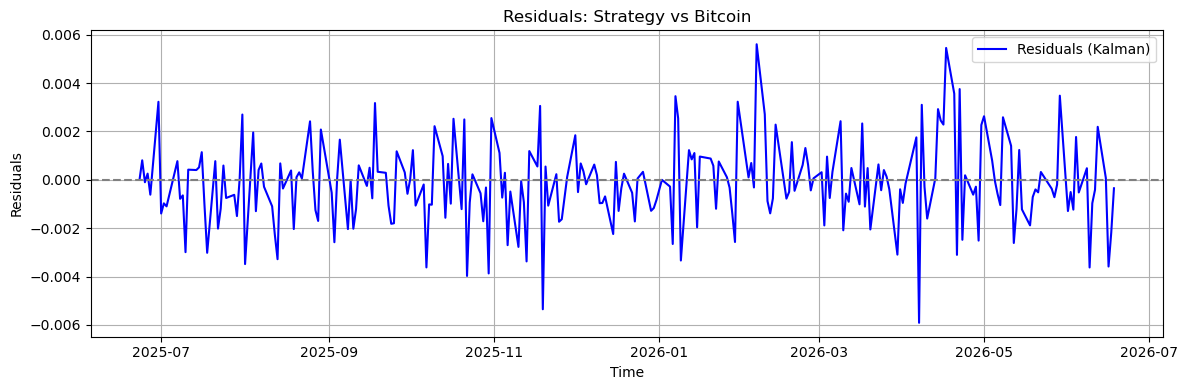

Average daily return: -0.00007
Daily volatility: 0.02528
Sharpe ratio (annualized): -0.06
Max drawdown: -0.30896


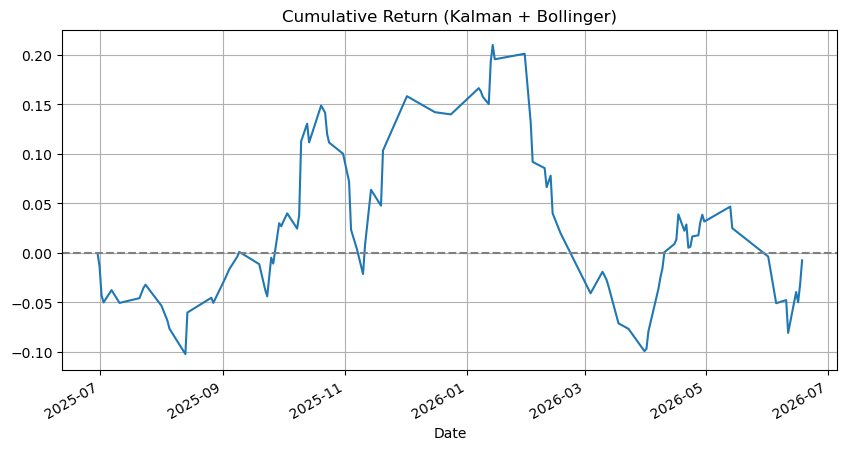

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_series(data, name, index):
    """
    Safely extracts the correct column even if yfinance returns a MultiIndex.
    """
    if isinstance(data, pd.Series):
        return pd.Series(data.values, index=index)
        
    if isinstance(data, pd.DataFrame):
        # If it is a yfinance MultiIndex, try to get 'Close' for this specific ticker
        if isinstance(data.columns, pd.MultiIndex):
            if 'Close' in data.columns.get_level_values(0):
                return pd.Series(data['Close'][name].values, index=index)
                
        # If it is a normal DataFrame, look for a column matching the name
        if name in data.columns:
            return pd.Series(data[name].values, index=index)
            
        # Fallback: take the first column if no names match
        return pd.Series(data.iloc[:, 0].values, index=index)
    
    # If input is a numpy array
    return pd.Series(np.array(data).flatten(), index=index)

def kalman_regression(x, y, delta=0.0001, Ve=0.001):
    """
    Runs dynamic linear regression using a Kalman Filter.
    Includes a numerical guard to prevent division by zero.
    """
    x = np.hstack([x, np.ones((x.shape[0], 1))])  # Add intercept term
    yhat = np.full(y.shape, np.nan)
    e = np.full(y.shape, np.nan)
    Q = np.full(y.shape, np.nan)
    
    P = 1e5 * np.eye(2)
    beta = np.full((2, x.shape[0]), np.nan)
    Vw = (delta / (1 - delta)) * np.eye(2)
    beta[:, 0] = 0
    
    for t in range(len(y)):
        if t > 0:
            beta[:, t] = beta[:, t - 1]
            R = P + Vw
        else:
            R = P
        
        yhat[t] = x[t, :] @ beta[:, t]
        
        # Numerical guard: Calculate Q first, then ensure it is not zero
        Q_t_scaled = x[t, :] @ R @ x[t, :].T + Ve
        if Q_t_scaled < 1e-10:
            Q_t_scaled = 1e-10
            
        Q[t] = Q_t_scaled
        e[t] = y[t] - yhat[t]
        
        # Calculate Kalman Gain safely
        K = R @ x[t, :].T / Q[t]
        beta[:, t] = beta[:, t] + K * e[t]
        P = R - np.outer(K, x[t, :]) @ R

    return beta, yhat, e, Q

# --- 3. Run Strategy and Generate Spread ---
log_btc_close = np.log(btc_close)
log_strategy_close = np.log(strategy_close)

x = log_btc_close.values.flatten()
y = log_strategy_close.values.flatten()
original_index = strategy_close.index

# Run Kalman filter
beta, yhat, e, Q = kalman_regression(x.reshape(-1, 1), y)

hedge_ratio = beta[0, :]
intercept = beta[1, :]

# Calculate the portfolio spread
yport = pd.Series(y - hedge_ratio * x - intercept, index=original_index)

# Plot Residuals
plt.figure(figsize=(12, 4))
plt.plot(yport, label='Residuals (Kalman)', color='blue')
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('Residuals: Strategy vs Bitcoin')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 4. Z-Score Signals ---
half_life = 22 
lookback = round(half_life)

def moving_avg(series, window):
    return series.rolling(window=window, min_periods=1).mean()

def moving_std(series, window):
    return series.rolling(window=window, min_periods=1).std()

# Calculate Rolling Z-Score
zScore = (yport - moving_avg(yport, lookback)) / moving_std(yport, lookback)

entryZscore = 1
exitZscore = 0
longsEntry = zScore < -entryZscore
longsExit = zScore >= -exitZscore
shortsEntry = zScore > entryZscore
shortsExit = zScore <= exitZscore

# --- 5. Position Generation (Fixed Logic) ---
numUnitsLong = pd.Series(np.nan, index=yport.index)
numUnitsShort = pd.Series(np.nan, index=yport.index)

numUnitsLong.iloc[0] = 0
numUnitsLong[longsEntry] = 1
numUnitsLong[longsExit] = 0
numUnitsLong = numUnitsLong.ffill()

numUnitsShort.iloc[0] = 0
numUnitsShort[shortsEntry] = -1
numUnitsShort[shortsExit] = 0
numUnitsShort = numUnitsShort.ffill()

numUnits = numUnitsLong + numUnitsShort

positions = pd.DataFrame(index=yport.index)
# Fixed Core Logic: If spread is low (numUnits=1), buy Strategy (y) and sell Bitcoin (x)
positions['strategy'] = numUnits 
positions['bitcoin'] = -numUnits * hedge_ratio

# --- 6. Backtesting and PnL Calculation ---
# Safely extract log-prices using the utility function
log_bitcoin = ensure_series(log_btc_close, 'BTC-USD', yport.index) 
log_strategy = ensure_series(log_strategy_close, 'Strategy', yport.index)

real_prices = np.exp(pd.DataFrame({
    'bitcoin': log_bitcoin,
    'strategy': log_strategy
}))

# Shift positions by 1 day to prevent lookahead bias
positions_lagged = positions.shift(1).fillna(0)

# Calculate Daily PnL and Returns
position_value = positions_lagged * real_prices
real_prices_diff = real_prices.diff().fillna(0)
pnl = (positions_lagged * real_prices_diff).sum(axis=1)

# Calculate Returns based on total invested capital
capital = position_value.abs().sum(axis=1)
ret = pnl / capital.replace(0, np.nan)

results = pd.DataFrame({
    'pnl': pnl,
    'ret': ret,
    'zScore': zScore,
    'spread': yport
}).dropna(subset=['ret'])

# Calculate Cumulative Returns
results['cum_ret'] = results['ret'].cumsum()

# --- 7. Metrics and Performance Charts ---
avg_daily_return = results['ret'].mean()
std_daily_return = results['ret'].std()
# Annualized Sharpe Ratio using 365 days (Crypto market standard)
sharpe_ratio = (avg_daily_return / std_daily_return) * np.sqrt(365) 
cum_max = results['cum_ret'].cummax()
drawdown = results['cum_ret'] - cum_max
max_drawdown = drawdown.min()

print(f"Average daily return: {avg_daily_return:.5f}")
print(f"Daily volatility: {std_daily_return:.5f}")
print(f"Sharpe ratio (annualized): {sharpe_ratio:.2f}")
print(f"Max drawdown: {max_drawdown:.5f}")

# Plot Cumulative Performance
plt.figure(figsize=(10,5))
results['cum_ret'].plot(title='Cumulative Return (Kalman + Bollinger)')
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.show()

## Strategy Evaluation

### Absolute vs Risk-Adjusted Return

The strategy clearly shows a negative performance, which validates the initial statistical analysis that indicated a low probability of stationarity.


